In [1]:
import legume

import numpy as np
import matplotlib.pyplot as plt
import time

import autograd.numpy as npa
from autograd import grad, value_and_grad

import legume
from legume.minimize import Minimize

%load_ext autoreload
%autoreload 2

# PhC cavity simulation

Bandgap: 0.2562 – 0.3375,  centre f_target = 0.2968


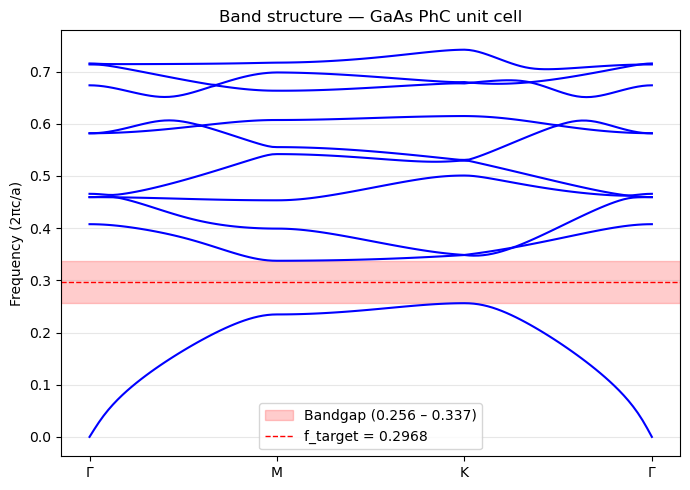

In [2]:
# ── Band structure of the perfect PhC (unit cell) ──────────────────────────
# Parameters match the cavity cell below (GaAs: ra=0.3, dslab=0.6, n_slab=3.46)
_ra, _dslab, _n_slab = 0.3, 0.6, 3.46

lattice_unit = legume.Lattice('hexagonal')
phc_unit = legume.PhotCryst(lattice_unit)
phc_unit.add_layer(d=_dslab, eps_b=_n_slab**2)
phc_unit.add_shape(legume.Circle(x_cent=0, y_cent=0, r=_ra))

path_dict = lattice_unit.bz_path(['G', 'M', 'K', 'G'], [40, 40, 40])
kpoints = path_dict['kpoints']

gme_bands = legume.GuidedModeExp(phc_unit, gmax=4.0, truncate_g='tbt')
gme_bands.run(kpoints=kpoints, gmode_inds=[0], verbose=False, numeig=10)

# Find the largest complete bandgap
freqs_b = gme_bands.freqs
f_lb, f_ub, f_target = None, None, None
best_gap = 0
for i in range(freqs_b.shape[1] - 1):
    top = np.max(freqs_b[:, i])
    bot = np.min(freqs_b[:, i + 1])
    if bot > top and (bot - top) > best_gap:
        best_gap = bot - top
        f_lb, f_ub = top, bot
        f_target = (top + bot) / 2

print(f"Bandgap: {f_lb:.4f} – {f_ub:.4f},  centre f_target = {f_target:.4f}")

# Plot band structure
fig, ax = plt.subplots(figsize=(7, 5))
for i in range(freqs_b.shape[1]):
    ax.plot(freqs_b[:, i], 'b-', lw=1.5)
ax.axhspan(f_lb, f_ub, alpha=0.2, color='red',
           label=f'Bandgap ({f_lb:.3f} – {f_ub:.3f})')
ax.axhline(f_target, color='red', ls='--', lw=1,
           label=f'f_target = {f_target:.4f}')
ax.set_xticks([0, 40, 80, 120])
ax.set_xticklabels(['Γ', 'M', 'K', 'Γ'])
ax.set_ylabel('Frequency (2πc/a)')
ax.set_title('Band structure — GaAs PhC unit cell')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

<Axes: xlabel='Wave vector', ylabel='Frequency $\\omega a /(2\\pi c)$'>

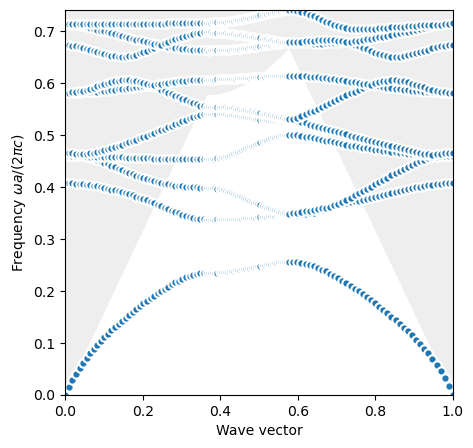

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
legume.viz.bands(gme_bands, ax=ax, k_units=True, Q=False)

In [3]:
# Number of PhC periods in x and y directions
Nx, Ny = 16, 10

# Regular PhC parameters
ra = 0.3
dslab = 0.6
n_slab = 3.46

# Initialize a lattice and PhC
lattice = legume.Lattice([Nx, 0], [0, Ny*np.sqrt(3)/2])

# Make x and y positions in one quadrant of the supercell
# We only initialize one quadrant because we want to shift the holes symmetrically
xp, yp = [], []
nx, ny = Nx//2 + 1, Ny//2 + 1
for iy in range(ny):
    for ix in range(nx):
        # Skip the 3 L3 cavity holes:
        #   (ix=0, iy=0) → origin hole (1 hole)
        #   (ix=1, iy=0) → (1,0) and its (-1,0) mirror (2 holes)
        if iy == 0 and ix in (0, 1):
            continue
        xp.append(ix + (iy%2)*0.5)
        yp.append(iy*np.sqrt(3)/2)

nc = len(xp)

# Initialize shift parameters to zeros
dx, dy = np.zeros((nc,)), np.zeros((nc,))

In [33]:

# Define L3 PhC cavity with shifted holes
def cavity(dx, dy):
    # Initialize PhC
    phc = legume.PhotCryst(lattice)

    # Add a layer to the PhC
    phc.add_layer(d=dslab, eps_b=n_slab**2)

    # Apply holes symmetrically in the four quadrants
    for ic, x in enumerate(xp):
        yc = yp[ic] if yp[ic] == 0 else yp[ic] + dy[ic]
        xc = x if x == 0 else xp[ic] + dx[ic]
        phc.add_shape(legume.Circle(x_cent=xc, y_cent=yc, r=ra))
        if nx-0.6 > xp[ic] > 0 and (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=-yc, r=ra))
        if nx-1.6 > xp[ic] > 0:
            phc.add_shape(legume.Circle(x_cent=-xc, y_cent=yc, r=ra))
        if (ny-1.1)*np.sqrt(3)/2 > yp[ic] > 0 and nx-1.1 > xp[ic]:
            phc.add_shape(legume.Circle(x_cent=xc, y_cent=-yc, r=ra))

    return phc


In [34]:
# Solve for a cavity defined by shifts dx, dy
def gme_cavity(dx, dy, gmax, truncate_g, options):
    # Initialize PhC
    phc = cavity(dx, dy)

    # For speed, we don't want to compute the loss rates of *all* modes that we store
    options['compute_im'] = False

    # Initialize GME
    gme = legume.GuidedModeExp(phc, gmax=gmax, truncate_g=truncate_g)

    # Solve for the real part of the frequencies
    gme.run(kpoints=np.array([[0], [0]]), **options)

    # Find the imaginary frequency of the fundamental cavity mode
    (freq_im, _, _) = gme.compute_rad(0, [mode_idx])

    # Finally, compute the quality factor
    Q = gme.freqs[0, mode_idx]/2/freq_im[0]
    return (gme, Q)

In [35]:
gmax = 2
truncate_g = 'tbt'  # for large rectangular supercells better to use tbt, it is faster and uses less memory
options = {'gmode_inds': [0], 'verbose': True, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Run GME directly for the initial mode-identification pass
phc_init = cavity(dx, dy)
gme = legume.GuidedModeExp(phc_init, gmax=gmax, truncate_g=truncate_g)
gme.run(kpoints=np.array([[0], [0]]), **{**options, 'compute_im': False})

# Identify the L3 cavity mode (first mode inside the bandgap)
print(f"\nModes near bandgap centre (bandgap: {f_lb:.4f} – {f_ub:.4f}):")
mode_idx = None
for i in range(gme.freqs.shape[1]):
    (freq_im_i, _, _) = gme.compute_rad(0, [i])
    Qi = gme.freqs[0, i] / (2 * freq_im_i[0])
    in_gap = f_lb < gme.freqs[0, i] < f_ub
    tag = " <-- cavity mode (IN BANDGAP)" if in_gap else ""
    print(f"  Mode {i}: f = {gme.freqs[0, i]:.5f},  Q = {Qi:.1f}{tag}")
    if in_gap and mode_idx is None:
        mode_idx = i

if mode_idx is None:
    raise RuntimeError("No mode found inside the bandgap — check f_lb/f_ub or increase numeig")
print(f"\nUsing mode_idx = {mode_idx}")

# Compute Q for the identified cavity mode
(freq_im, _, _) = gme.compute_rad(0, [mode_idx])
Q = gme.freqs[0, mode_idx] / (2 * freq_im[0])

16.249s total time for real part of frequencies in GuidedModeExp, of which
  0.163s (1%) for guided modes computation using the gmode_compute='exact' method
  0.696s (4%) for inverse matrix of Fourier-space permittivity
  13.707s (84%) for matrix diagionalization using the 'eigh' solver
  1.682s (10%) for creating GME matrix
Skipping imaginary part computation, use run_im() to run it, or compute_rad() to compute the radiative rates of selected eigenmodes

Modes near bandgap centre (bandgap: 0.2562 – 0.3375):
  Mode 0: f = 0.26627,  Q = 5882.0 <-- cavity mode (IN BANDGAP)
  Mode 1: f = 0.28646,  Q = 666.8 <-- cavity mode (IN BANDGAP)
  Mode 2: f = 0.28673,  Q = 562.3 <-- cavity mode (IN BANDGAP)
  Mode 3: f = 0.28865,  Q = 246.2 <-- cavity mode (IN BANDGAP)
  Mode 4: f = 0.29074,  Q = 298.8 <-- cavity mode (IN BANDGAP)
  Mode 5: f = 0.31634,  Q = 631.4 <-- cavity mode (IN BANDGAP)
  Mode 6: f = 0.33081,  Q = 4733.9 <-- cavity mode (IN BANDGAP)
  Mode 7: f = 0.33457,  Q = 435069.6 <-- ca

Cavity quality factor: 5882.03


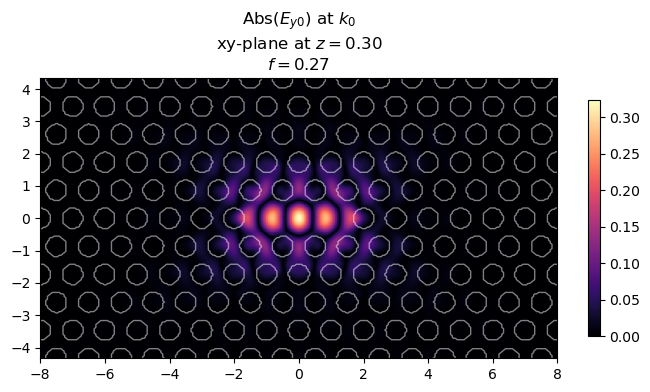

In [36]:
# Print the computed quality factor
print("Cavity quality factor: %1.2f" %Q)

# We can also visualize the cavity and the mode profile of the fundamental mode
ax = legume.viz.field(gme, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=300, N2=200)

## Autograd backend

In [37]:
# To compute gradients, we need to set the `legume` backend to 'autograd'
legume.set_backend('autograd')

# Set GME options — use eig_sigma so the solver targets modes near the bandgap centre
gmax = 2
truncate_g = 'tbt'
options = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
           'eig_sigma': f_target, 'gradients': 'approx'}

# Define an objective function: only optimize the symmetric x-shift of the two end holes
# (ic=0, xp=2.0, yp=0) — Akahane et al. end-hole shift
def of_Q(params):
    # params[0] = x-shift of the two end holes adjacent to the L3 cavity
    dx_full = npa.concatenate([params[0:1], npa.zeros(nc - 1)])
    dy_full = npa.zeros(nc)
    (gme, Q) = gme_cavity(dx_full, dy_full, gmax=gmax, truncate_g=truncate_g, options=options)

    # We put a negative sign because we use in-built methods to *minimize* the objective function
    return -Q

## Test gradient of quality factor

In [38]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_Q)

# We do the numerical check w.r.t. the end-hole shift (the only parameter)
ind0 = 0
# We set the starting parameter to zero, i.e. un-modified cavity
pstart = np.zeros((1,))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1]
# Print the gradient w.r.t. the parameter index ind0
print("Autograd gradient:  %1.4f, computed in %1.4fs" %(grad_a[ind0], time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_Q(p_test) - of_Q(pstart))/1e-5
print("Numerical gradient: %1.4f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a[ind0] - grad_n)/grad_n))


Autograd gradient:  -47223.3398, computed in 18.8420s
Numerical gradient: -47226.1136, computed in 35.0078s
Relative difference: 5.87e-05


## test gradient of fields

In [39]:
# Define an objective function which is proportional to the V of the fundamental mode
def of_V(params):
    dx = params[0:nc]
    dy = params[nc:]
    (gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)

    # Get the electric field in the center of the slab
    Ey = gme.get_field_xy('e', kind=0, mind=mode_idx, z=dslab/2, component='y', Nx=3, Ny=3)[0]['y']

    # Notice the use of autograd.numpy (npa) and not plain numpy (np)
    return 1/npa.square(npa.amax(npa.abs(Ey)))


In [40]:
# The autograd function `value_and_grad` returns simultaneously the objective value and the gradient
obj_grad = value_and_grad(of_V)

# We do the numerical check w.r.t. the closest hole to the center
ind0 = 0
# We set the starting parameters to zeros, i.e. un-modified cavity
pstart = np.zeros((2*nc, ))

# Compute the autograd gradients (NB: all at once!)
t = time.time()
grad_a = obj_grad(pstart)[1][ind0]
print("Autograd gradient:  %1.8f, computed in %1.4fs" %(grad_a, time.time() - t))

# Compute a numerical gradient for one selected index
t = time.time()
p_test = np.copy(pstart)
p_test[ind0] = p_test[ind0] + 1e-5
grad_n = (of_V(p_test) - of_V(pstart))/1e-5
print("Numerical gradient: %1.8f, computed in %1.4fs" %(grad_n, time.time() - t))

print("Relative difference: %1.2e" %np.abs((grad_a - grad_n)/grad_n))

/home/jonah/miniconda3/envs/photonics/lib/python3.12/site-packages/autograd/numpy/numpy_vjps.py:620: ComplexWarning: Casting complex values to real discards the imaginary part
  return onp.asarray(out, dtype=A_dtype)


Autograd gradient:  14.84708549, computed in 17.5275s
Numerical gradient: 14.84720623, computed in 29.1912s
Relative difference: 8.13e-06


## Q factor optimization

In [41]:
# Initialize an optimization object
opt = Minimize(of_Q)

# Starting parameter: end-hole shift = 0 (un-modified cavity)
pstart = np.array([0.15])

# Run an 'adam' optimization
(p_opt, ofs) = opt.adam(pstart, step_size=0.02, Nepochs=50, bounds=[0, 0.25])

KeyboardInterrupt: 

Cavity quality factor: 90190.44
Optimized end-hole shift: dx[0] = 0.17771a


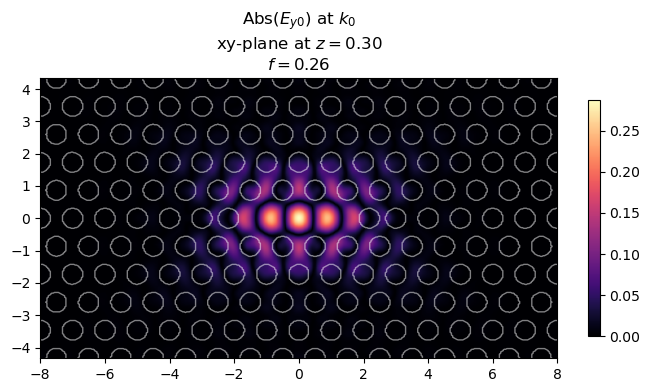

In [ ]:
# Optimized parameters — end-hole shift only
dx = np.zeros(nc)
dy = np.zeros(nc)
dx[0] = float(p_opt[0])

# Run the simulation
(gme, Q) = gme_cavity(dx, dy, gmax=gmax, truncate_g=truncate_g, options=options)
print("Cavity quality factor: %1.2f" % Q)
print(f"Optimized end-hole shift: dx[0] = {float(p_opt[0]):.5f}a")
ax = legume.viz.field(gme, 'e', 0, mode_idx, z=dslab/2, component='y', val='abs', N1=400, N2=400)

In [ ]:
# Plot Q vs optimization epoch (from the ofs array returned by opt.adam)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(ofs) + 1), -np.array(ofs), 'o-', lw=1.5, markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Q factor')
ax.set_title('Q factor during optimization')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Parameter sweep: Q vs end-hole shift
# Uses numpy backend for speed (no gradient overhead)
legume.set_backend('numpy')

shifts = np.linspace(0, 0.25, 15)
Qs_sweep = []
options_sweep = {'gmode_inds': [0], 'verbose': False, 'numeig': 10,
                 'eig_sigma': f_target, 'gradients': 'approx'}

print("Sweeping end-hole shift:")
for s in shifts:
    dx_s = np.zeros(nc); dx_s[0] = s
    dy_s = np.zeros(nc)
    (_, Q_s) = gme_cavity(dx_s, dy_s, gmax=2, truncate_g='tbt', options=options_sweep)
    Qs_sweep.append(Q_s)
    print(f"  shift = {s:.4f}a,  Q = {Q_s:.1f}")

# Plot Q vs shift, mark the optimizer result
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shifts, Qs_sweep, 'o-', lw=1.5, markersize=5, label='Sweep')
ax.axvline(float(p_opt[0]), color='red', ls='--', lw=1,
           label=f'Optimized shift = {float(p_opt[0]):.4f}a')
ax.set_xlabel('End-hole shift (a)')
ax.set_ylabel('Q factor')
ax.set_title('Q factor vs end-hole shift')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()